# Maritime Vessel Trajectory Clustering

**Objective:** Cluster vessel journeys from distance, speed, stop behavior, course variation, duration, and port-call patterns.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["distance_nm", "mean_speed_knots", "stop_hours", "course_variation", "duration_hours", "port_calls"]
PROFILE_CENTERS = {
  "short_feeder": [
    420,
    13,
    6,
    18,
    40,
    3
  ],
  "ocean_direct": [
    6200,
    17,
    2,
    8,
    370,
    2
  ],
  "multi_port": [
    2400,
    14,
    42,
    35,
    230,
    8
  ],
  "slow_steaming": [
    5100,
    11,
    4,
    10,
    470,
    2
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,distance_nm,mean_speed_knots,stop_hours,course_variation,duration_hours,port_calls,generator_profile
0,3075.036,11.607,38.899,32.843,210.431,7.138,multi_port
1,392.520,13.556,5.886,18.592,41.448,3.396,short_feeder
2,2518.151,13.131,35.355,32.394,228.742,8.933,multi_port
3,6203.730,17.762,2.233,9.318,381.456,2.118,ocean_direct
4,439.788,12.307,5.753,20.453,35.838,2.276,short_feeder


,count,mean,std,min,25%,50%,75%,max
distance_nm,492.0,3560.091,2323.786,295.490,1887.854,4141.170,5655.916,8170.889
mean_speed_knots,492.0,13.706,2.615,7.630,11.737,13.361,15.360,20.927
stop_hours,500.0,13.396,16.521,1.470,2.908,4.927,13.846,54.240
course_variation,500.0,17.751,10.750,5.636,9.041,13.009,22.986,41.028
duration_hours,500.0,277.733,165.578,30.360,143.374,288.453,416.107,590.908
port_calls,500.0,3.721,2.485,1.414,2.042,2.422,4.251,10.248


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=4 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.6844,0.4350
1,3,0.6295,0.5219
2,4,0.7025,0.3985
3,5,0.5630,0.9458
4,6,0.4716,1.0292


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.7025,0.3985
1,Agglomerative,0.6963,0.4056


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.9485


,records,distance_nm,mean_speed_knots,stop_hours,course_variation,duration_hours,port_calls
cluster,,,,,,,
0,125,416.470,12.909,6.021,17.998,39.814,2.967
1,125,2352.119,13.902,41.593,34.870,227.823,7.890
2,135,5229.006,11.067,3.831,9.925,463.552,2.019
3,115,6212.762,17.288,1.992,8.062,372.454,2.006


cluster,0,1,2,3,All
generator_profile,,,,,
multi_port,0,125,0,0,125
ocean_direct,0,0,10,115,125
short_feeder,125,0,0,0,125
slow_steaming,0,0,125,0,125
All,125,125,135,115,500


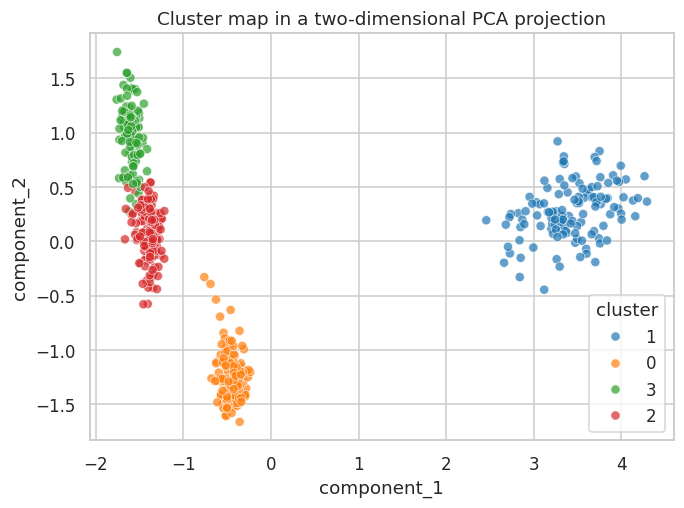

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,distance_nm,mean_speed_knots,stop_hours,course_variation,duration_hours,port_calls,predicted_cluster
0,4141.17,13.361,4.927,13.009,288.453,2.422,2


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
